# Adversarial Retraining – Attack Success Rate

This notebook plots Attack Success Rate (ASR) for two models across four attacks and saves the chart to `img` at 600 dpi.

Saved to /Users/leonurny/Desktop/Robustness-in-suffix-prediction/img/adversarial_retraining_asr.png


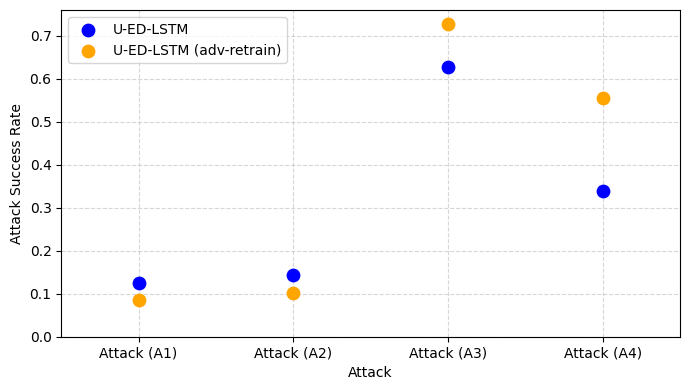

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Same colors as in automated_compare_robustness_models.ipynb: first model blue, second orange
MODEL_COLORS = ['blue', 'orange']

attacks = ["Attack (A1)", "Attack (A2)", "Attack (A3)", "Attack (A4)"]
models = ["U-ED-LSTM", "U-ED-LSTM (adv-retrain)"]
# Performance: for each attack, (U-ED-LSTM ASR, U-ED-LSTM adv-retrain ASR)
performance = [(0.1260, 0.0847), (0.1432, 0.1019), (0.6268, 0.7283), (0.3385, 0.5564)]

x = np.arange(len(attacks))

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

for model_idx, (model_name, color) in enumerate(zip(models, MODEL_COLORS)):
    asr = [p[model_idx] for p in performance]
    ax.scatter(x, asr, color=color, s=80, zorder=3, label=model_name)

ax.set_xticks(x)
ax.set_xticklabels(attacks)
ax.set_xlabel("Attack")
ax.set_ylabel("Attack Success Rate")
ax.set_xlim(-0.5, len(attacks) - 0.5)
ax.set_ylim(0, None)
ax.legend(loc='upper left')
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# img is at project root: from robustness/evaluator go up twice to project root
out_dir = Path("../../img").resolve()
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "adversarial_retraining_asr.png"
fig.savefig(out_path, dpi=600, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()